In [ ]:
# ============================================
# TaskA_04_CXR_seed固定再学習
# 1. 実行環境確認 + 乱数seed固定
# ============================================

import os
import sys
import random
import numpy as np
import torch
import torchvision

SEED = 42

def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))

print("Device:", device)
print("Random seed:", SEED)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
CUDA: 12.8
GPU: Tesla T4
Device: cuda
Random seed: 42


In [ ]:
# ============================================
# 2. Google Drive接続 + パス設定
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

SPLIT_CSV = os.path.join(
    BASE_DIR,
    "00_共通・研究管理",
    "03_患者選定",
    "COVID19_固定患者split_1277.csv"
)

PNG_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "01_前処理",
    "processed_png_1277"
)

print("Split CSV exists:", os.path.exists(SPLIT_CSV))
print("PNG dir exists:", os.path.exists(PNG_DIR))

Mounted at /content/drive
Split CSV exists: True
PNG dir exists: True


In [ ]:
# ============================================
# 3. 固定splitの読み込み・確認
# ============================================

split_df = pd.read_csv(SPLIT_CSV)

print("Columns:")
print(split_df.columns.tolist())

print("\nSplit counts:")
print(split_df["split"].value_counts())

print("\nOutcome by split:")
print(
    split_df.groupby("split")["true_label"]
    .agg(["count", "sum", "mean"])
)

print("\nTotal:", len(split_df))
print("Unique Subject ID:", split_df["Subject ID"].nunique())

Columns:
['Subject ID', 'to_patient_id', 'last.status', 'true_label', 'split']

Split counts:
split
train    1021
val       128
test      128
Name: count, dtype: int64

Outcome by split:
       count  sum      mean
split                      
test     128   17  0.132812
train   1021  135  0.132223
val      128   17  0.132812

Total: 1277
Unique Subject ID: 1277


In [ ]:
# ============================================
# 4. Transform設定
# ============================================

from torchvision import transforms

# Train: Augmentation A
train_transform_A = transforms.Compose([
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Train: Augmentation B
train_transform_B = transforms.Compose([
    transforms.RandomAffine(
        degrees=5,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation / Test: augmentationなし
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================
# 5. Dataset定義
# ============================================

from torch.utils.data import Dataset
from PIL import Image
import torch

class CXRDataset(Dataset):
    def __init__(self, dataframe, png_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.png_dir = png_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        patient_id = str(row["Subject ID"])
        label = int(row["true_label"])

        image_path = os.path.join(
            self.png_dir,
            f"{patient_id}.png"
        )

        image = Image.open(image_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.float32),
            "patient_id": patient_id
        }

In [ ]:
# ============================================
# 6. Train / Val / Test dataframe
# ============================================

train_df = split_df[split_df["split"] == "train"].copy()
val_df   = split_df[split_df["split"] == "val"].copy()
test_df  = split_df[split_df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1021
Val: 128
Test: 128


In [ ]:
# ============================================
# 7. Dataset / DataLoader 構築
# ============================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 0

# Dataset
train_dataset_A = CXRDataset(
    train_df,
    PNG_DIR,
    transform=train_transform_A
)

train_dataset_B = CXRDataset(
    train_df,
    PNG_DIR,
    transform=train_transform_B
)

val_dataset = CXRDataset(
    val_df,
    PNG_DIR,
    transform=eval_transform
)

test_dataset = CXRDataset(
    test_df,
    PNG_DIR,
    transform=eval_transform
)

# DataLoaderのshuffle用generator
generator_A = torch.Generator()
generator_A.manual_seed(SEED)

generator_B = torch.Generator()
generator_B.manual_seed(SEED)

train_loader_A = DataLoader(
    train_dataset_A,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    generator=generator_A
)

train_loader_B = DataLoader(
    train_dataset_B,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    generator=generator_B
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train A:", len(train_dataset_A))
print("Train B:", len(train_dataset_B))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Batch size:", BATCH_SIZE)
print("num_workers:", NUM_WORKERS)

Train A: 1021
Train B: 1021
Val: 128
Test: 128
Batch size: 32
num_workers: 0


In [ ]:
batch = next(iter(train_loader_A))

print("Image shape:", batch["image"].shape)
print("Label shape:", batch["label"].shape)
print("Patient IDs:", batch["patient_id"][:5])
print("Labels:", batch["label"][:5])

Image shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Patient IDs: ['A558243', 'A811401', 'A345917', 'A138005', 'A355016']
Labels: tensor([0., 0., 0., 0., 0.])


In [ ]:
# ============================================
# 8. ResNet18モデル定義
# ============================================

import torch.nn as nn
from torchvision import models

def build_resnet18(seed=42):
    # 各条件で同じ乱数状態から開始
    seed_everything(seed)

    weights = models.ResNet18_Weights.IMAGENET1K_V1

    model = models.resnet18(weights=weights)

    # 二値分類用に最終層を置換
    model.fc = nn.Linear(512, 1)

    # full fine-tuning
    for param in model.parameters():
        param.requires_grad = True

    model = model.to(device)

    return model

In [ ]:
model = build_resnet18(SEED)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("Model:", model.__class__.__name__)
print("Final layer:", model.fc)
print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)
print("Full fine-tuning:", trainable_params == total_params)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]


Model: ResNet
Final layer: Linear(in_features=512, out_features=1, bias=True)
Trainable parameters: 11177025
Total parameters: 11177025
Full fine-tuning: True


In [ ]:
# ============================================
# 9. 学習・評価関数
# ============================================

from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        loss.backward()

        # 今回はgradient clippingは使用しない
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)

        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)

    return epoch_loss, roc_auc, pr_auc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)

    return epoch_loss, roc_auc, pr_auc

In [ ]:
# ============================================
# 10. 1条件分の学習関数
# ============================================

import os
import pandas as pd

def train_model_condition(
    condition_name,
    train_loader,
    val_loader,
    lr,
    pos_weight=None,
    max_epochs=30,
    seed=42
):

    # -------------------------
    # 各条件を同じseedから開始
    # -------------------------
    seed_everything(seed)

    model = build_resnet18(seed)

    # -------------------------
    # Loss
    # -------------------------
    if pos_weight is None:
        criterion = nn.BCEWithLogitsLoss()
    else:
        pw = torch.tensor(
            [pos_weight],
            dtype=torch.float32,
            device=device
        )
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    # -------------------------
    # Optimizer
    # -------------------------
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    # -------------------------
    # Best checkpoint用
    # -------------------------
    best_val_auc = -np.inf
    best_val_loss = np.inf
    best_epoch = None

    # -------------------------
    # Early stopping用
    # -------------------------
    early_stop_best_auc = -np.inf
    early_stop_counter = 0
    early_stop_patience = 8
    min_delta = 0.001

    history = []

    checkpoint_path = os.path.join(
        TRAINING_DIR,
        f"{condition_name}_best.pth"
    )

    history_path = os.path.join(
        TRAINING_DIR,
        f"{condition_name}_history.csv"
    )

    # -------------------------
    # Training loop
    # -------------------------
    for epoch in range(1, max_epochs + 1):

        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_auc, train_pr_auc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_auc, val_pr_auc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_loss,
            "train_roc_auc": train_auc,
            "train_pr_auc": train_pr_auc,
            "val_loss": val_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_pr_auc
        })

        print(
            f"Epoch {epoch:02d} | "
            f"LR {current_lr:.2e} | "
            f"Train Loss {train_loss:.4f} "
            f"AUC {train_auc:.4f} "
            f"PR {train_pr_auc:.4f} | "
            f"Val Loss {val_loss:.4f} "
            f"AUC {val_auc:.4f} "
            f"PR {val_pr_auc:.4f}"
        )

        # ====================================
        # Best checkpoint
        # Val ROC-AUCの純粋な最大値
        # 同値ならVal lossが低い方
        # ====================================
        checkpoint_improved = False

        if val_auc > best_val_auc:
            checkpoint_improved = True

        elif val_auc == best_val_auc and val_loss < best_val_loss:
            checkpoint_improved = True

        if checkpoint_improved:
            best_val_auc = val_auc
            best_val_loss = val_loss
            best_epoch = epoch

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "val_roc_auc": val_auc,
                    "val_pr_auc": val_pr_auc,
                    "val_loss": val_loss,
                    "condition_name": condition_name,
                    "seed": seed,
                    "lr": lr,
                    "pos_weight": pos_weight
                },
                checkpoint_path
            )

        # -------------------------
        # Scheduler
        # -------------------------
        scheduler.step(val_loss)

        # ====================================
        # Early stopping
        # min_deltaはここだけで使用
        # ====================================
        if val_auc > early_stop_best_auc + min_delta:
            early_stop_best_auc = val_auc
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= early_stop_patience:
            print(
                f"Early stopping at epoch {epoch}"
            )
            break

    # -------------------------
    # History保存
    # -------------------------
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    print("\n==============================")
    print("Condition:", condition_name)
    print("Best epoch:", best_epoch)
    print("Best Val ROC-AUC:", round(best_val_auc, 4))
    print("Best Val loss:", round(best_val_loss, 4))
    print("Checkpoint:", checkpoint_path)
    print("==============================")

    return history_df

In [ ]:
# ============================================
# 11. 学習結果保存先
# ============================================

TRAINING_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "04_Training"
)

os.makedirs(TRAINING_DIR, exist_ok=True)

print("Training directory:")
print(TRAINING_DIR)
print("Exists:", os.path.exists(TRAINING_DIR))

Training directory:
/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training
Exists: True


In [ ]:
# ============================================
# 12. 技術確認（2 epochのみ）
# 本番結果には使用しない
# ============================================

tech_history = train_model_condition(
    condition_name="TECH_AugA_LR1e-5",
    train_loader=train_loader_A,
    val_loader=val_loader,
    lr=1e-5,
    pos_weight=None,
    max_epochs=2,
    seed=SEED
)

Epoch 01 | LR 1.00e-05 | Train Loss 0.6399 AUC 0.6876 PR 0.2470 | Val Loss 0.4918 AUC 0.7255 PR 0.2916
Epoch 02 | LR 1.00e-05 | Train Loss 0.5499 AUC 0.8351 PR 0.5215 | Val Loss 0.5101 AUC 0.8023 PR 0.4525

Condition: TECH_AugA_LR1e-5
Best epoch: 2
Best Val ROC-AUC: 0.8023
Best Val loss: 0.5101
Checkpoint: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training/TECH_AugA_LR1e-5_best.pth


In [ ]:
def make_train_loader(dataset, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        generator=g
    )

In [ ]:
train_loader = make_train_loader(train_dataset_A, SEED)

In [ ]:
# ============================================
# 13. 本番 Stage 1：6条件比較
# seed=42 固定
# ============================================

stage1_results = {}

conditions = [
    ("AugA_LR1e-5_seed42", train_dataset_A, 1e-5),
    ("AugA_LR3e-5_seed42", train_dataset_A, 3e-5),
    ("AugA_LR1e-4_seed42", train_dataset_A, 1e-4),
    ("AugB_LR1e-5_seed42", train_dataset_B, 1e-5),
    ("AugB_LR3e-5_seed42", train_dataset_B, 3e-5),
    ("AugB_LR1e-4_seed42", train_dataset_B, 1e-4),
]

for condition_name, dataset, lr in conditions:

    print("\n\n########################################")
    print("START:", condition_name)
    print("########################################")

    # 各条件でshuffle generatorをseed=42から再作成
    train_loader = make_train_loader(
        dataset,
        seed=SEED
    )

    history_df = train_model_condition(
        condition_name=condition_name,
        train_loader=train_loader,
        val_loader=val_loader,
        lr=lr,
        pos_weight=None,
        max_epochs=30,
        seed=SEED
    )

    stage1_results[condition_name] = history_df



########################################
START: AugA_LR1e-5_seed42
########################################
Epoch 01 | LR 1.00e-05 | Train Loss 0.6387 AUC 0.6949 PR 0.2602 | Val Loss 0.4833 AUC 0.7398 PR 0.3043
Epoch 02 | LR 1.00e-05 | Train Loss 0.5507 AUC 0.8321 PR 0.4914 | Val Loss 0.4948 AUC 0.8066 PR 0.4441
Epoch 03 | LR 1.00e-05 | Train Loss 0.4881 AUC 0.8755 PR 0.5633 | Val Loss 0.4789 AUC 0.8124 PR 0.5087
Epoch 04 | LR 1.00e-05 | Train Loss 0.4265 AUC 0.9129 PR 0.7097 | Val Loss 0.4431 AUC 0.8129 PR 0.5032
Epoch 05 | LR 1.00e-05 | Train Loss 0.3789 AUC 0.9350 PR 0.7442 | Val Loss 0.4203 AUC 0.8135 PR 0.5102
Epoch 06 | LR 1.00e-05 | Train Loss 0.3393 AUC 0.9444 PR 0.8014 | Val Loss 0.3804 AUC 0.8071 PR 0.5067
Epoch 07 | LR 1.00e-05 | Train Loss 0.3037 AUC 0.9635 PR 0.8458 | Val Loss 0.3722 AUC 0.8172 PR 0.5070
Epoch 08 | LR 1.00e-05 | Train Loss 0.2750 AUC 0.9664 PR 0.8521 | Val Loss 0.3557 AUC 0.8151 PR 0.5015
Epoch 09 | LR 1.00e-05 | Train Loss 0.2404 AUC 0.9800 PR 0.9019 | 

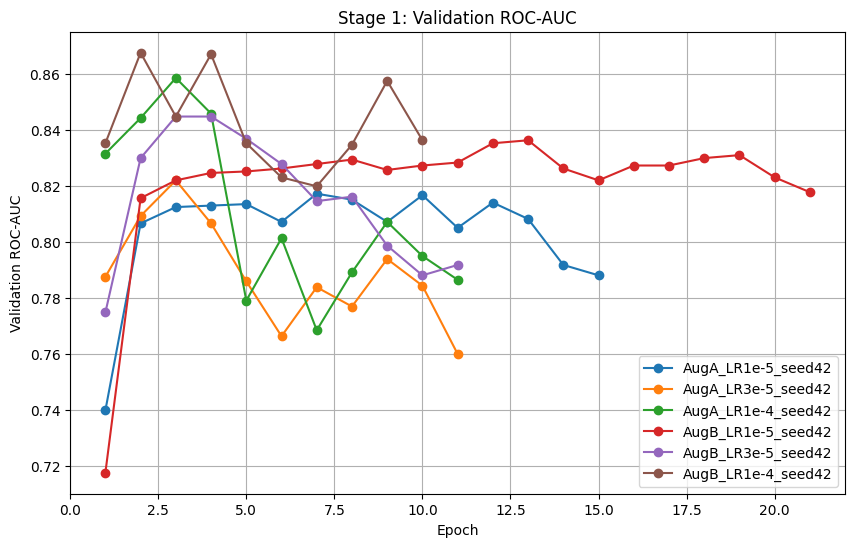

In [ ]:
# ============================================
# 15. Stage 1 学習曲線の可視化
# Validation ROC-AUC
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for condition_name, history_df in stage1_results.items():
    plt.plot(
        history_df["epoch"],
        history_df["val_roc_auc"],
        marker="o",
        label=condition_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation ROC-AUC")
plt.title("Stage 1: Validation ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

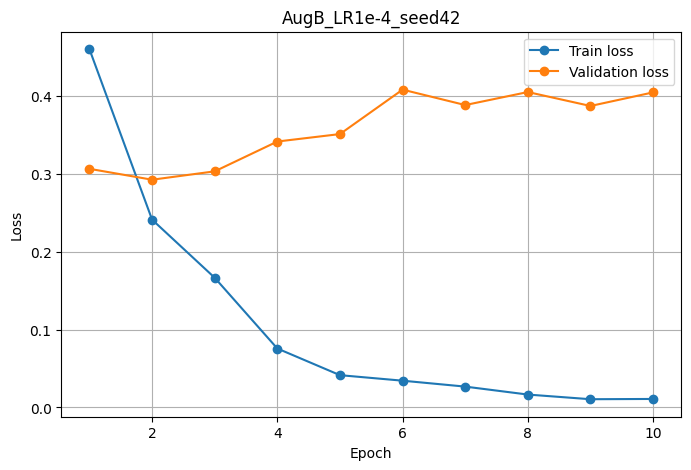

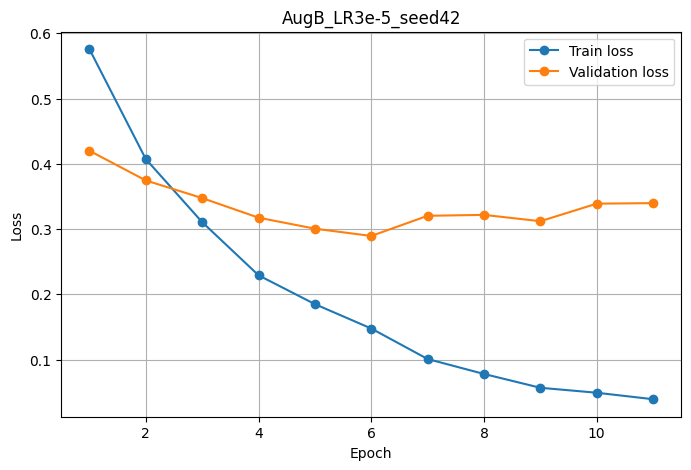

In [ ]:
# ============================================
# 17. Train / Validation loss
# ============================================

for condition_name in [
    "AugB_LR1e-4_seed42",
    "AugB_LR3e-5_seed42"
]:
    history_df = stage1_results[condition_name]

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(condition_name)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# ============================================
# 18. Stage 1 過学習指標の比較
# ============================================

overfit_rows = []

for condition_name, history_df in stage1_results.items():

    # Val ROC-AUC 最大
    max_val_auc = history_df["val_roc_auc"].max()

    best_candidates = history_df[
        history_df["val_roc_auc"] == max_val_auc
    ]

    # 完全同値ならVal lossが低いepoch
    best_row = best_candidates.loc[
        best_candidates["val_loss"].idxmin()
    ]

    best_epoch = int(best_row["epoch"])

    # Val loss最小epoch
    min_loss_row = history_df.loc[
        history_df["val_loss"].idxmin()
    ]

    # best epoch以降の最終Val AUC
    final_row = history_df.iloc[-1]

    overfit_rows.append({
        "condition": condition_name,
        "best_epoch": best_epoch,
        "train_auc_at_best": best_row["train_roc_auc"],
        "val_auc_at_best": best_row["val_roc_auc"],
        "auc_gap_at_best": (
            best_row["train_roc_auc"]
            - best_row["val_roc_auc"]
        ),
        "val_pr_auc_at_best": best_row["val_pr_auc"],
        "val_loss_at_best": best_row["val_loss"],
        "min_val_loss": min_loss_row["val_loss"],
        "min_val_loss_epoch": int(min_loss_row["epoch"]),
        "final_train_auc": final_row["train_roc_auc"],
        "final_val_auc": final_row["val_roc_auc"]
    })

overfit_summary = pd.DataFrame(overfit_rows)

overfit_summary = overfit_summary.sort_values(
    "val_auc_at_best",
    ascending=False
).reset_index(drop=True)

display(overfit_summary)

,condition,best_epoch,train_auc_at_best,val_auc_at_best,auc_gap_at_best,val_pr_auc_at_best,val_loss_at_best,min_val_loss,min_val_loss_epoch,final_train_auc,final_val_auc
0,AugB_LR1e-4_seed42,2,0.920717,0.867515,0.053203,0.538257,0.292366,0.292366,2,1.000000,0.836248
1,AugA_LR1e-4_seed42,3,0.989758,0.858506,0.131253,0.539939,0.295324,0.293761,2,1.000000,0.786433
2,AugB_LR3e-5_seed42,4,0.965287,0.844727,0.120560,0.598491,0.317467,0.289447,6,0.999958,0.791733
3,AugB_LR1e-5_seed42,13,0.988379,0.836248,0.152131,0.540356,0.300597,0.300597,13,0.999139,0.817700
4,AugA_LR3e-5_seed42,3,0.948374,0.821940,0.126434,0.541733,0.363482,0.321203,6,1.000000,0.759936
5,AugA_LR1e-5_seed42,7,0.963540,0.817170,0.146370,0.507019,0.372238,0.316446,13,0.997425,0.788023


In [ ]:
# ============================================
# 19. Stage 2：class weight なし／あり 比較
# 条件固定：AugB + LR=1e-5 + seed=42
# ============================================

POS_WEIGHT = 886 / 135

stage2_results = {}

# -------------------------
# 1. class weightなし
# -------------------------
train_loader_unweighted = make_train_loader(
    train_dataset_B,
    seed=SEED
)

history_unweighted = train_model_condition(
    condition_name="AugB_LR1e-5_seed42_unweighted",
    train_loader=train_loader_unweighted,
    val_loader=val_loader,
    lr=1e-5,
    pos_weight=None,
    max_epochs=30,
    seed=SEED
)

stage2_results["unweighted"] = history_unweighted


# -------------------------
# 2. class weightあり
# -------------------------
train_loader_weighted = make_train_loader(
    train_dataset_B,
    seed=SEED
)

history_weighted = train_model_condition(
    condition_name="AugB_LR1e-5_seed42_weighted",
    train_loader=train_loader_weighted,
    val_loader=val_loader,
    lr=1e-5,
    pos_weight=POS_WEIGHT,
    max_epochs=30,
    seed=SEED
)

stage2_results["weighted"] = history_weighted

print("\npos_weight:", POS_WEIGHT)

Epoch 01 | LR 1.00e-05 | Train Loss 0.6392 AUC 0.6968 PR 0.2482 | Val Loss 0.5000 AUC 0.7175 PR 0.3029
Epoch 02 | LR 1.00e-05 | Train Loss 0.5556 AUC 0.8247 PR 0.4470 | Val Loss 0.4965 AUC 0.8156 PR 0.4265
Epoch 03 | LR 1.00e-05 | Train Loss 0.4957 AUC 0.8566 PR 0.5278 | Val Loss 0.4889 AUC 0.8219 PR 0.4842
Epoch 04 | LR 1.00e-05 | Train Loss 0.4321 AUC 0.9071 PR 0.6966 | Val Loss 0.4482 AUC 0.8246 PR 0.5076
Epoch 05 | LR 1.00e-05 | Train Loss 0.3928 AUC 0.9110 PR 0.6905 | Val Loss 0.4210 AUC 0.8251 PR 0.5069
Epoch 06 | LR 1.00e-05 | Train Loss 0.3596 AUC 0.9143 PR 0.7196 | Val Loss 0.3802 AUC 0.8262 PR 0.5132
Epoch 07 | LR 1.00e-05 | Train Loss 0.3179 AUC 0.9486 PR 0.7883 | Val Loss 0.3585 AUC 0.8278 PR 0.5088
Epoch 08 | LR 1.00e-05 | Train Loss 0.2904 AUC 0.9514 PR 0.8081 | Val Loss 0.3521 AUC 0.8294 PR 0.5428
Epoch 09 | LR 1.00e-05 | Train Loss 0.2611 AUC 0.9623 PR 0.8540 | Val Loss 0.3395 AUC 0.8256 PR 0.5415
Epoch 10 | LR 1.00e-05 | Train Loss 0.2384 AUC 0.9654 PR 0.8697 | Val Los

In [ ]:
# ============================================
# 20. Stage 2 比較表
# ============================================

stage2_summary_rows = []

for weight_name, history_df in stage2_results.items():

    max_auc = history_df["val_roc_auc"].max()

    candidates = history_df[
        history_df["val_roc_auc"] == max_auc
    ]

    best_row = candidates.loc[
        candidates["val_loss"].idxmin()
    ]

    min_loss_row = history_df.loc[
        history_df["val_loss"].idxmin()
    ]

    stage2_summary_rows.append({
        "class_weight": weight_name,
        "best_epoch": int(best_row["epoch"]),
        "train_auc_at_best": best_row["train_roc_auc"],
        "val_auc_at_best": best_row["val_roc_auc"],
        "auc_gap_at_best":
            best_row["train_roc_auc"] - best_row["val_roc_auc"],
        "val_pr_auc_at_best": best_row["val_pr_auc"],
        "val_loss_at_best": best_row["val_loss"],
        "min_val_loss": min_loss_row["val_loss"],
        "min_val_loss_epoch": int(min_loss_row["epoch"])
    })

stage2_summary = pd.DataFrame(stage2_summary_rows)

display(stage2_summary)

stage2_summary.to_csv(
    os.path.join(
        TRAINING_DIR,
        "TaskA_stage2_class_weight比較_seed42.csv"
    ),
    index=False
)

,class_weight,best_epoch,train_auc_at_best,val_auc_at_best,auc_gap_at_best,val_pr_auc_at_best,val_loss_at_best,min_val_loss,min_val_loss_epoch
0,unweighted,13,0.988379,0.836248,0.152131,0.540356,0.300597,0.300597,13
1,weighted,12,0.984959,0.848967,0.135993,0.560622,0.857041,0.834321,8


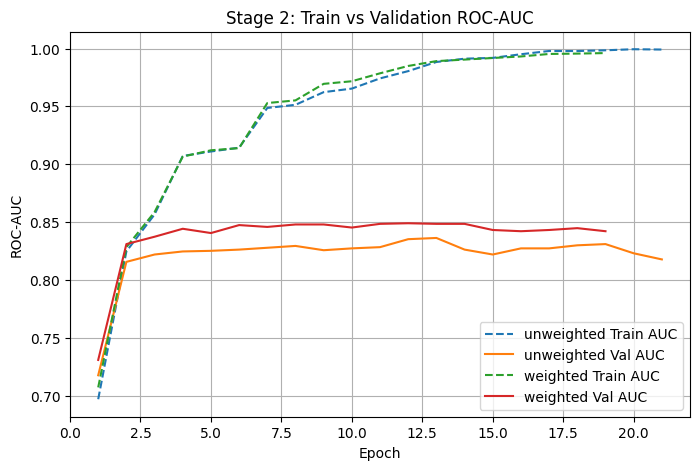

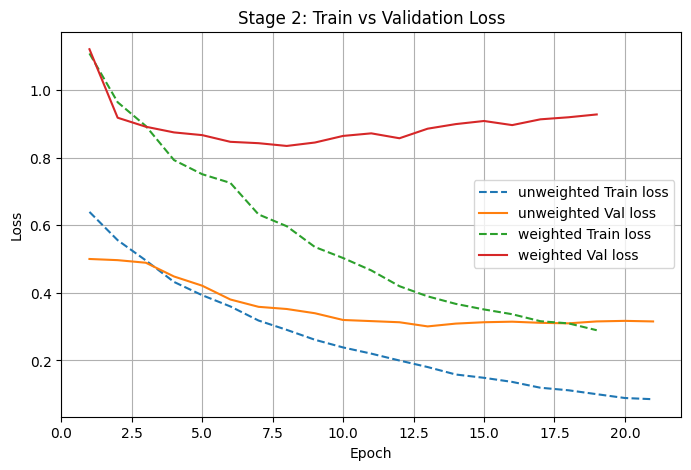

In [ ]:
# ============================================
# 21. Stage 2 学習曲線の比較
# ============================================

import matplotlib.pyplot as plt

# ROC-AUC
plt.figure(figsize=(8, 5))

for name, history_df in stage2_results.items():
    plt.plot(
        history_df["epoch"],
        history_df["train_roc_auc"],
        linestyle="--",
        label=f"{name} Train AUC"
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_roc_auc"],
        label=f"{name} Val AUC"
    )

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Stage 2: Train vs Validation ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()


# Loss
plt.figure(figsize=(8, 5))

for name, history_df in stage2_results.items():
    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        linestyle="--",
        label=f"{name} Train loss"
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label=f"{name} Val loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2: Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
# ============================================
# TaskA_04
# 保存済みhistory/checkpointから
# 学習・Validation結果を整理して保存
# ※再学習は行わない
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import json
import pandas as pd
import numpy as np
import torch

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

TRAINING_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "04_Training"
)

os.makedirs(TRAINING_DIR, exist_ok=True)

print("TRAINING_DIR:", TRAINING_DIR)

Mounted at /content/drive
TRAINING_DIR: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training


In [2]:
# ============================================
# 1. 保存済みファイルを監査
# ============================================

history_files = sorted(
    glob.glob(os.path.join(TRAINING_DIR, "*history.csv"))
)

checkpoint_files = sorted(
    glob.glob(os.path.join(TRAINING_DIR, "*best.pth"))
)

print("=== History files ===")
for f in history_files:
    print(os.path.basename(f))

print("\n=== Checkpoint files ===")
for f in checkpoint_files:
    print(os.path.basename(f))

print("\nHistory n   :", len(history_files))
print("Checkpoint n:", len(checkpoint_files))

=== History files ===
AugA_LR1e-4_history.csv
AugA_LR1e-4_seed42_history.csv
AugA_LR1e-5_history.csv
AugA_LR1e-5_seed42_history.csv
AugA_LR1e-5_weighted_history.csv
AugA_LR3e-5_history.csv
AugA_LR3e-5_seed42_history.csv
AugB_LR1e-4_history.csv
AugB_LR1e-4_seed42_history.csv
AugB_LR1e-5_history.csv
AugB_LR1e-5_seed42_history.csv
AugB_LR1e-5_seed42_unweighted_history.csv
AugB_LR1e-5_seed42_weighted_history.csv
AugB_LR3e-5_history.csv
AugB_LR3e-5_seed42_history.csv
TECH_AugA_LR1e-5_history.csv

=== Checkpoint files ===
AugA_LR1e-4_seed42_best.pth
AugA_LR1e-5_seed42_best.pth
AugA_LR3e-5_seed42_best.pth
AugB_LR1e-4_seed42_best.pth
AugB_LR1e-5_seed42_best.pth
AugB_LR1e-5_seed42_unweighted_best.pth
AugB_LR1e-5_seed42_weighted_best.pth
AugB_LR3e-5_seed42_best.pth
TECH_AugA_LR1e-5_best.pth

History n   : 16
Checkpoint n: 9


In [3]:
# ============================================
# TaskA_04 正式再学習結果の集約・保存
# seed=42 の結果のみを対象
# 再学習は行わない
# ============================================

import os
import pandas as pd
import numpy as np
import torch

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

TRAINING_DIR = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "04_Training"
)

# --------------------------------------------------
# Stage 1: 6 conditions
# --------------------------------------------------

stage1_conditions = [
    "AugA_LR1e-5_seed42",
    "AugA_LR3e-5_seed42",
    "AugA_LR1e-4_seed42",
    "AugB_LR1e-5_seed42",
    "AugB_LR3e-5_seed42",
    "AugB_LR1e-4_seed42",
]

stage1_rows = []

for condition in stage1_conditions:

    history_path = os.path.join(
        TRAINING_DIR,
        f"{condition}_history.csv"
    )

    checkpoint_path = os.path.join(
        TRAINING_DIR,
        f"{condition}_best.pth"
    )

    history = pd.read_csv(history_path)

    ckpt = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    best_epoch = int(ckpt["epoch"])

    # epoch列が1始まりの場合
    if "epoch" in history.columns:
        best_row = history[
            history["epoch"] == best_epoch
        ].iloc[0]
    else:
        best_row = history.iloc[best_epoch - 1]

    stage1_rows.append({
        "condition": condition,
        "best_epoch": best_epoch,
        "train_loss": best_row.get("train_loss", np.nan),
        "train_roc_auc": best_row.get("train_roc_auc", np.nan),
        "train_pr_auc": best_row.get("train_pr_auc", np.nan),
        "val_loss": best_row.get("val_loss", np.nan),
        "val_roc_auc": best_row.get("val_roc_auc", ckpt.get("val_roc_auc", np.nan)),
        "val_pr_auc": best_row.get("val_pr_auc", ckpt.get("val_pr_auc", np.nan)),
        "checkpoint": os.path.basename(checkpoint_path),
        "history_file": os.path.basename(history_path)
    })

stage1_df = pd.DataFrame(stage1_rows)

stage1_path = os.path.join(
    TRAINING_DIR,
    "TaskA_CXR_Stage1_seed42_6条件比較.csv"
)

stage1_df.to_csv(stage1_path, index=False)

print("=== Stage 1 ===")
display(stage1_df)
print("Saved:", stage1_path)


# --------------------------------------------------
# Stage 2: unweighted vs weighted
# --------------------------------------------------

stage2_conditions = [
    "AugB_LR1e-5_seed42_unweighted",
    "AugB_LR1e-5_seed42_weighted",
]

stage2_rows = []

for condition in stage2_conditions:

    history_path = os.path.join(
        TRAINING_DIR,
        f"{condition}_history.csv"
    )

    checkpoint_path = os.path.join(
        TRAINING_DIR,
        f"{condition}_best.pth"
    )

    history = pd.read_csv(history_path)

    ckpt = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    best_epoch = int(ckpt["epoch"])

    if "epoch" in history.columns:
        best_row = history[
            history["epoch"] == best_epoch
        ].iloc[0]
    else:
        best_row = history.iloc[best_epoch - 1]

    stage2_rows.append({
        "condition": condition,
        "best_epoch": best_epoch,
        "train_loss": best_row.get("train_loss", np.nan),
        "train_roc_auc": best_row.get("train_roc_auc", np.nan),
        "train_pr_auc": best_row.get("train_pr_auc", np.nan),
        "val_loss": best_row.get("val_loss", np.nan),
        "val_roc_auc": best_row.get("val_roc_auc", ckpt.get("val_roc_auc", np.nan)),
        "val_pr_auc": best_row.get("val_pr_auc", ckpt.get("val_pr_auc", np.nan)),
        "pos_weight": ckpt.get("pos_weight", np.nan),
        "checkpoint": os.path.basename(checkpoint_path),
        "history_file": os.path.basename(history_path)
    })

stage2_df = pd.DataFrame(stage2_rows)

stage2_path = os.path.join(
    TRAINING_DIR,
    "TaskA_CXR_Stage2_classweight比較.csv"
)

stage2_df.to_csv(stage2_path, index=False)

print("\n=== Stage 2 ===")
display(stage2_df)
print("Saved:", stage2_path)


# --------------------------------------------------
# Final selected model summary
# --------------------------------------------------

final_ckpt_path = os.path.join(
    TRAINING_DIR,
    "AugB_LR1e-5_seed42_weighted_best.pth"
)

final_ckpt = torch.load(
    final_ckpt_path,
    map_location="cpu",
    weights_only=False
)

final_summary = pd.DataFrame([{
    "model": "ImageNet-1K pretrained ResNet18",
    "fine_tuning": "full fine-tuning",
    "augmentation": "B",
    "augmentation_detail":
        "translation ±2%; scale 0.98-1.02; brightness 0.95-1.05; "
        "contrast 0.95-1.05; rotation ±5°; no flip",
    "initial_lr": 1e-5,
    "optimizer": "AdamW",
    "weight_decay": 1e-4,
    "loss": "BCEWithLogitsLoss",
    "class_weight": "pos_weight",
    "pos_weight": final_ckpt.get(
        "pos_weight",
        886 / 135
    ),
    "seed": final_ckpt.get("seed", 42),
    "batch_size": 32,
    "num_workers": 0,
    "max_epochs": 30,
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 3,
    "scheduler_min_lr": 1e-6,
    "early_stopping_metric": "Validation ROC-AUC",
    "early_stopping_patience": 8,
    "early_stopping_min_improvement": 0.001,
    "best_epoch": final_ckpt["epoch"],
    "val_roc_auc": final_ckpt["val_roc_auc"],
    "val_pr_auc": final_ckpt["val_pr_auc"],
    "val_loss": final_ckpt["val_loss"],
    "checkpoint":
        "AugB_LR1e-5_seed42_weighted_best.pth"
}])

final_summary_path = os.path.join(
    TRAINING_DIR,
    "TaskA_CXR_最終学習条件サマリー.csv"
)

final_summary.to_csv(
    final_summary_path,
    index=False
)

print("\n=== Final selected model ===")
display(final_summary)
print("Saved:", final_summary_path)

=== Stage 1 ===


,condition,best_epoch,train_loss,train_roc_auc,train_pr_auc,val_loss,val_roc_auc,val_pr_auc,checkpoint,history_file
0,AugA_LR1e-5_seed42,7,0.303669,0.963540,0.845832,0.372238,0.817170,0.507019,AugA_LR1e-5_seed42_best.pth,AugA_LR1e-5_seed42_history.csv
1,AugA_LR3e-5_seed42,3,0.295433,0.948374,0.800380,0.363482,0.821940,0.541733,AugA_LR3e-5_seed42_best.pth,AugA_LR3e-5_seed42_history.csv
2,AugA_LR1e-4_seed42,3,0.123754,0.989758,0.952125,0.295324,0.858506,0.539939,AugA_LR1e-4_seed42_best.pth,AugA_LR1e-4_seed42_history.csv
3,AugB_LR1e-5_seed42,13,0.180371,0.988379,0.942586,0.300597,0.836248,0.540356,AugB_LR1e-5_seed42_best.pth,AugB_LR1e-5_seed42_history.csv
4,AugB_LR3e-5_seed42,4,0.229164,0.965287,0.874034,0.317467,0.844727,0.598491,AugB_LR3e-5_seed42_best.pth,AugB_LR3e-5_seed42_history.csv
5,AugB_LR1e-4_seed42,2,0.241093,0.920717,0.711432,0.292366,0.867515,0.538257,AugB_LR1e-4_seed42_best.pth,AugB_LR1e-4_seed42_history.csv


Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training/TaskA_CXR_Stage1_seed42_6条件比較.csv

=== Stage 2 ===


,condition,best_epoch,train_loss,train_roc_auc,train_pr_auc,val_loss,val_roc_auc,val_pr_auc,pos_weight,checkpoint,history_file
0,AugB_LR1e-5_seed42_unweighted,13,0.180371,0.988379,0.942586,0.300597,0.836248,0.540356,NaN,AugB_LR1e-5_seed42_unweighted_best.pth,AugB_LR1e-5_seed42_unweighted_history.csv
1,AugB_LR1e-5_seed42_weighted,12,0.419496,0.984959,0.906563,0.857041,0.848967,0.560622,6.562963,AugB_LR1e-5_seed42_weighted_best.pth,AugB_LR1e-5_seed42_weighted_history.csv


Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training/TaskA_CXR_Stage2_classweight比較.csv

=== Final selected model ===


,model,fine_tuning,augmentation,augmentation_detail,initial_lr,optimizer,weight_decay,loss,class_weight,pos_weight,...,scheduler_patience,scheduler_min_lr,early_stopping_metric,early_stopping_patience,early_stopping_min_improvement,best_epoch,val_roc_auc,val_pr_auc,val_loss,checkpoint
0,ImageNet-1K pretrained ResNet18,full fine-tuning,B,translation ±2%; scale 0.98-1.02; brightness 0...,0.00001,AdamW,0.0001,BCEWithLogitsLoss,pos_weight,6.562963,...,3,0.000001,Validation ROC-AUC,8,0.001,12,0.848967,0.560622,0.857041,AugB_LR1e-5_seed42_weighted_best.pth


Saved: /content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training/TaskA_CXR_最終学習条件サマリー.csv
